
# 📈 Portfolio Analytics (PA) — Returns, Risk & Sharpe with Exports

This notebook computes and **exports to a folder named `pa/`** :

- **Log daily returns** and **Simple daily returns** (CSV)
- **Equally-weighted portfolio** daily returns (CSV)
- **Annualized return**, **Annualized volatility**, **Sharpe ratio (Rf = 1%)** (CSV)
- **Correlation matrix** (CSV)
- **Charts:** Portfolio cumulative return (`portfolio_cumulative_return.png`) and Rolling 20D annualized volatility (`portfolio_rolling_vol_20d.png`)





##  Data Ingestion
- Robust header detection (if headers are embedded below the first row)
- Export path: a local folder named **`pa/`**


In [1]:

%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

FILES = {
    "Equity": "Equity.xlsx",
    "Fixed Income": "Fixed Income.xlsx",
    "Commodity": "Commodity.xlsx",
}
DATE_COL = "Date"
PRICE_COL = "Close Price"
TRADING_DAYS = 252
RF = 0.01  # 1% annual risk-free rate

outdir = Path("pa")
outdir.mkdir(exist_ok=True)
print("Outputs will be saved under:", outdir.resolve())

def load_series(name, fname):
    p = Path(fname)
    if not p.exists():
        print(f"⚠️ Missing file: {fname}. Skipping this asset.")
        return None
    try:
        df = pd.read_excel(p)
    except Exception:
        df = None
    if df is None or DATE_COL not in df.columns or PRICE_COL not in df.columns:
        raw = pd.read_excel(p, header=None)
        header_row = None
        for i in range(min(80, len(raw))):
            vals = raw.iloc[i].astype(str).str.strip().str.lower().tolist()
            if "date" in vals and ("close price" in vals or "close" in vals):
                header_row = i
                break
        if header_row is not None:
            df = pd.read_excel(p, header=header_row)
        elif df is None:
            raise RuntimeError(f"Could not detect headers in {fname}")
    cols = {c: str(c).strip() for c in df.columns}
    df = df.rename(columns=cols)
    if "Close" in df.columns and "Close Price" not in df.columns:
        df = df.rename(columns={"Close": "Close Price"})
    if DATE_COL not in df.columns or "Close Price" not in df.columns:
        raise RuntimeError(f"Required columns not found in {fname}. Found columns: {list(df.columns)}")
    df = df[[DATE_COL, "Close Price"]].copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL, "Close Price"]).sort_values(DATE_COL)
    df = df.rename(columns={"Close Price": name}).set_index(DATE_COL)
    return df

series = []
for name, fname in FILES.items():
    s = load_series(name, fname)
    if s is not None:
        series.append(s)

if len(series) >= 2:
    price_df = pd.concat(series, axis=1, join="inner").dropna(how="any")
    data_loaded = True
    display(price_df.tail())
    price_df.to_csv(outdir / "aligned_prices.csv")
else:
    data_loaded = False
    print("⚠️ Not enough assets loaded. Please ensure the Excel files exist next to this notebook.")


Outputs will be saved under: D:\central bank interview\Portfolio_Analysis\pa


,Equity,Fixed Income,Commodity
Date,,,
2025-09-29,6661.21,23.06,352.46
2025-09-30,6688.46,23.06,355.47
2025-10-01,6711.20,23.10,356.03
2025-10-02,6715.35,23.12,354.79
2025-10-03,6715.79,23.09,357.64



## 📅 Daily Returns — Simple & Log (CSV)
- **Simple**: `price.pct_change()` — intuitive for portfolio math
- **Log**: `log(price).diff()` — time-additive, useful for modeling


In [2]:

if data_loaded:
    simple_rets = price_df.pct_change().dropna()
    log_rets = np.log(price_df).diff().dropna()
    display(simple_rets.tail())
    display(log_rets.tail())
    simple_rets.to_csv(outdir / "daily_returns_simple.csv")
    log_rets.to_csv(outdir / "daily_returns_log.csv")
    print("Saved:", (outdir/"daily_returns_simple.csv").resolve())
    print("Saved:", (outdir/"daily_returns_log.csv").resolve())
else:
    print("⏭️ Skipping returns: data not loaded.")


,Equity,Fixed Income,Commodity
Date,,,
2025-09-29,0.002636,0.002173,0.016497
2025-09-30,0.004091,0.000000,0.008540
2025-10-01,0.003400,0.001735,0.001575
2025-10-02,0.000618,0.000866,-0.003483
2025-10-03,0.000066,-0.001298,0.008033


,Equity,Fixed Income,Commodity
Date,,,
2025-09-29,0.002632,0.002171,0.016362
2025-09-30,0.004083,0.000000,0.008504
2025-10-01,0.003394,0.001733,0.001574
2025-10-02,0.000618,0.000865,-0.003489
2025-10-03,0.000066,-0.001298,0.008001


Saved: D:\central bank interview\Portfolio_Analysis\pa\daily_returns_simple.csv
Saved: D:\central bank interview\Portfolio_Analysis\pa\daily_returns_log.csv



## 🧺 Equally-Weighted Portfolio Daily Returns (CSV)
Weights = 1/N across all assets.


In [3]:

if data_loaded:
    n = simple_rets.shape[1]
    weights = np.repeat(1.0/n, n)
    port_rets = (simple_rets @ weights).rename("Portfolio")
    display(port_rets.tail())
    port_rets.to_csv(outdir / "portfolio_daily_returns.csv")
    print("Saved:", (outdir/"portfolio_daily_returns.csv").resolve())
else:
    print("⏭️ Skipping portfolio returns: data not loaded.")


Date
2025-09-29    0.007102
2025-09-30    0.004210
2025-10-01    0.002237
2025-10-02   -0.000666
2025-10-03    0.002267
Name: Portfolio, dtype: float64

Saved: D:\central bank interview\Portfolio_Analysis\pa\portfolio_daily_returns.csv



## 📊 Annualized Return, Volatility, Sharpe (Rf = 1%) (CSV)
- **Annualized Return**: \((1+\bar r_{daily})^{252} - 1\)
- **Annualized Volatility**: \(\sigma_{daily}\times\sqrt{252}\)
- **Sharpe Ratio**: \(\frac{R_{annual} - R_f}{\sigma_{annual}}\), with \(R_f=1\%\)


In [4]:

if data_loaded:
    avg_daily = port_rets.mean()
    ann_return = (1 + avg_daily)**TRADING_DAYS - 1
    ann_vol = port_rets.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - RF) / ann_vol if ann_vol != 0 else np.nan
    metrics = pd.DataFrame({
        "Annualized Return": [ann_return],
        "Annualized Volatility": [ann_vol],
        "Sharpe Ratio (Rf=1%)": [sharpe]
    })
    display(metrics.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio (Rf=1%)": "{:.2f}"
    }))
    metrics.to_csv(outdir / "portfolio_metrics.csv", index=False)
    print("Saved:", (outdir/"portfolio_metrics.csv").resolve())
else:
    print("⏭️ Skipping metrics: data not loaded.")


,Annualized Return,Annualized Volatility,Sharpe Ratio (Rf=1%)
0,11.52%,9.77%,1.08


Saved: D:\central bank interview\Portfolio_Analysis\pa\portfolio_metrics.csv



## 🔗 Correlation Matrix (CSV)
Pairwise correlations between assets (simple daily returns).


In [5]:

if data_loaded:
    corr = simple_rets.corr()
    display(corr)
    corr.to_csv(outdir / "correlation_matrix.csv")
    print("Saved:", (outdir/"correlation_matrix.csv").resolve())
else:
    print("⏭️ Skipping correlations: data not loaded.")


,Equity,Fixed Income,Commodity
Equity,1.000000,-0.119330,0.132877
Fixed Income,-0.119330,1.000000,0.308961
Commodity,0.132877,0.308961,1.000000


Saved: D:\central bank interview\Portfolio_Analysis\pa\correlation_matrix.csv



## 📈 Charts: Cumulative Return & Rolling 20D Volatility (PNG)
- **Cumulative Return**: growth of $1 invested
- **Rolling 20D Volatility**: annualized, highlights regime changes


Saved charts in: D:\central bank interview\Portfolio_Analysis\pa


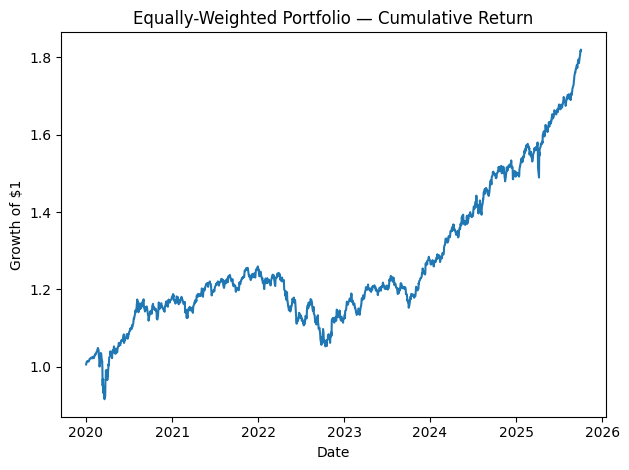

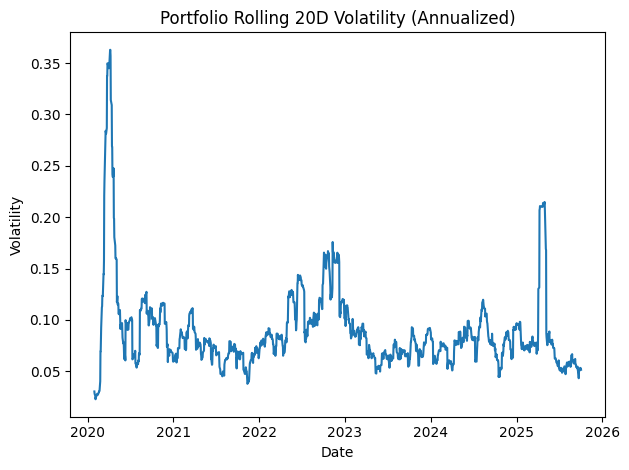

In [6]:

if data_loaded:
    cum = (1 + port_rets).cumprod()
    plt.figure()
    plt.plot(cum.index, cum.values)
    plt.title("Equally-Weighted Portfolio — Cumulative Return")
    plt.xlabel("Date"); plt.ylabel("Growth of $1"); plt.tight_layout()
    plt.savefig(outdir / "portfolio_cumulative_return.png")

    roll20 = port_rets.rolling(20).std() * np.sqrt(TRADING_DAYS)
    plt.figure()
    plt.plot(roll20.index, roll20.values)
    plt.title("Portfolio Rolling 20D Volatility (Annualized)")
    plt.xlabel("Date"); plt.ylabel("Volatility"); plt.tight_layout()
    plt.savefig(outdir / "portfolio_rolling_vol_20d.png")
    print("Saved charts in:", outdir.resolve())
else:
    print("⏭️ Skipping charts: data not loaded.")





**Annualized Volatility**  
- It’s the **typical annual variability** of returns (σ_daily × √252).  
- Lower σ = more stable; higher σ = more variable. 

**Sharpe Ratio**  
- Measures **excess return per unit of risk**: (Annualized Return − 1%)/Annualized Volatility.  
- Rules of thumb: **<1** improvable, **1–2** decent, **>2** strong.  



